# Affective Rewrites Dataset — Statistics
Statistical overview of `affective_rewrites.csv`: source/split distributions, affective dimension breakdown, VAD score descriptives, and inter-score correlations.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

## 2. Load and Preview the Dataset

In [2]:
CSV_PATH = "../dataset/rewrites/affective_rewrites.csv"

df_raw = pd.read_csv(CSV_PATH, header=0)
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (22580, 18)


,source_dataset,source_split,source_id,base_text,positive_rewrite,negative_rewrite,preserved_meaning_score,positive_description,negative_description,base_valence,base_arousal,base_dominance,positive_valence,positive_arousal,positive_dominance,negative_valence,negative_arousal,negative_dominance
0,empatheticdialogues,all,ed_all_10615,I went to a circus recently and was thought it...,"I went to a circus recently, expecting it to b...",I went to a circus recently and thought it mig...,0.95,The positive rewrite intensifies the excitemen...,The negative rewrite tones down the excitement...,0.78,0.55,0.65,0.90,0.80,0.70,0.65,0.35,0.60
1,empatheticdialogues,all,ed_all_63514,We just bought a used car and we've already ha...,"We just bought a used car, and it's so frustra...",We recently bought a used car and have had to ...,0.95,The positive rewrite increases emotional inten...,The negative rewrite reduces emotional intensi...,0.40,0.50,0.50,0.35,0.75,0.50,0.40,0.30,0.50
2,empatheticdialogues,all,ed_all_53520,I had a c-section planned to deliver my baby. ...,I had a c-section planned to deliver my baby. ...,I had a c-section planned to deliver my baby. ...,0.95,Increasing the emotional intensity by expressi...,Decreasing the emotional intensity by expressi...,0.75,0.55,0.50,0.85,0.75,0.60,0.65,0.35,0.45
3,empatheticdialogues,all,ed_all_39682,I'm going to the waterpark tomorrow! It's my f...,I can't wait to go to the waterpark tomorrow! ...,I'm going to the waterpark tomorrow. It's my f...,0.95,More explicit excitement and enthusiasm about ...,More restrained and neutral expression about t...,0.80,0.65,0.70,0.90,0.85,0.75,0.70,0.40,0.65
4,empatheticdialogues,all,ed_all_21364,My partner left the city to go visit her paren...,"My partner left the city to visit her parents,...",My partner left the city to visit her parents....,0.95,More explicitly expresses loneliness and emoti...,"More restrained and neutral, reducing expresse...",0.30,0.40,0.40,0.25,0.65,0.35,0.28,0.25,0.45


## 3. Assign Column Names and Basic Info

In [3]:
COLUMNS = [
    "source_dataset", "source_split", "source_id",
    "base_text", "positive_rewrite", "negative_rewrite",
    "preserved_meaning_score",
    "positive_description", "negative_description",
    "base_valence", "base_arousal", "base_dominance",
    "positive_valence", "positive_arousal", "positive_dominance",
    "negative_valence", "negative_arousal", "negative_dominance",
]

VAD_COLS = COLUMNS[10:]  # all 9 numeric VAD scores

df = df_raw.copy()
df.columns = COLUMNS

print("Dtypes:")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())
print("\nUnique values per categorical column:")
for col in ["source_dataset", "source_split"]:
    print(f"  {col}: {df[col].nunique()} → {df[col].unique().tolist()}")

Dtypes:
source_dataset                 str
source_split                   str
source_id                      str
base_text                      str
positive_rewrite               str
negative_rewrite               str
preserved_meaning_score    float64
positive_description           str
negative_description           str
base_valence               float64
base_arousal               float64
base_dominance             float64
positive_valence           float64
positive_arousal           float64
positive_dominance         float64
negative_valence           float64
negative_arousal           float64
negative_dominance         float64
dtype: object

Null counts:
source_dataset             0
source_split               0
source_id                  0
base_text                  0
positive_rewrite           0
negative_rewrite           0
preserved_meaning_score    0
positive_description       0
negative_description       0
base_valence               0
base_arousal               0
base_dominance 

## 4. Distribution of Data Sources and Splits

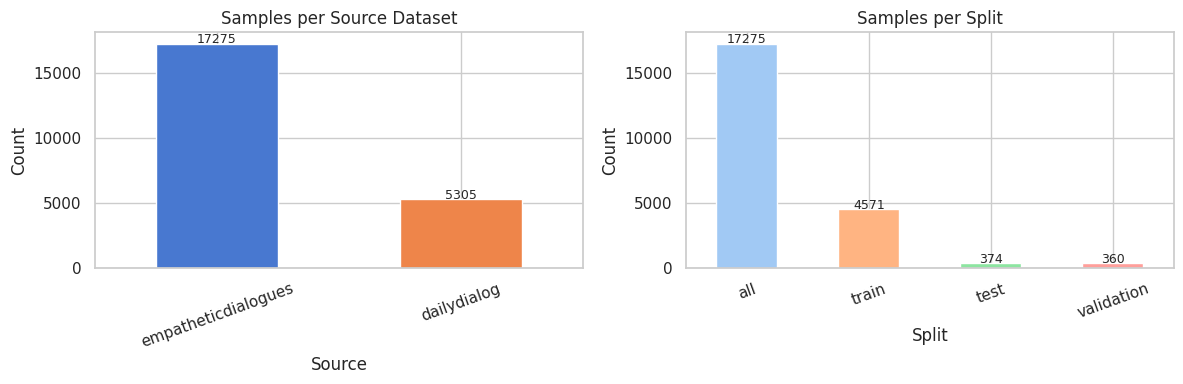


Source dataset counts:
source_dataset
empatheticdialogues    17275
dailydialog             5305

Split counts:
source_split
all           17275
train          4571
test            374
validation      360


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Source dataset
src_counts = df["source_dataset"].value_counts()
src_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted"))
axes[0].set_title("Samples per Source Dataset")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(src_counts):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=9)

# Source split
split_counts = df["source_split"].value_counts()
split_counts.plot(kind="bar", ax=axes[1], color=sns.color_palette("pastel"))
axes[1].set_title("Samples per Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(split_counts):
    axes[1].text(i, v + 5, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nSource dataset counts:")
print(src_counts.to_string())
print("\nSplit counts:")
print(split_counts.to_string())

## 6. Numeric Score Statistics

The 9 numeric scores are VAD (Valence–Arousal–Dominance) ratings for base, positive rewrite, and negative rewrite variants, plus `preserved_meaning_score`.

In [5]:
score_cols = ["preserved_meaning_score"] + VAD_COLS
desc = df[score_cols].describe().T
desc.index.name = "score"
desc

,count,mean,std,min,25%,50%,75%,max
score,,,,,,,,
preserved_meaning_score,22580.0,0.951504,0.010869,0.85,0.95,0.95,0.95,1.00
base_arousal,22580.0,0.499820,0.105618,0.20,0.40,0.50,0.55,0.85
base_dominance,22580.0,0.525842,0.098254,0.10,0.50,0.50,0.60,0.85
positive_valence,22580.0,0.613494,0.259015,0.05,0.35,0.70,0.85,0.98
positive_arousal,22580.0,0.718534,0.105412,0.30,0.65,0.75,0.80,0.98
positive_dominance,22580.0,0.559749,0.142382,0.05,0.48,0.60,0.65,0.95
negative_valence,22580.0,0.516801,0.158091,0.05,0.40,0.50,0.65,0.90
negative_arousal,22580.0,0.321894,0.084601,0.10,0.25,0.30,0.40,0.65
negative_dominance,22580.0,0.506783,0.075551,0.15,0.45,0.50,0.55,0.80


## 7. Score Distributions by Affective Axis

/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


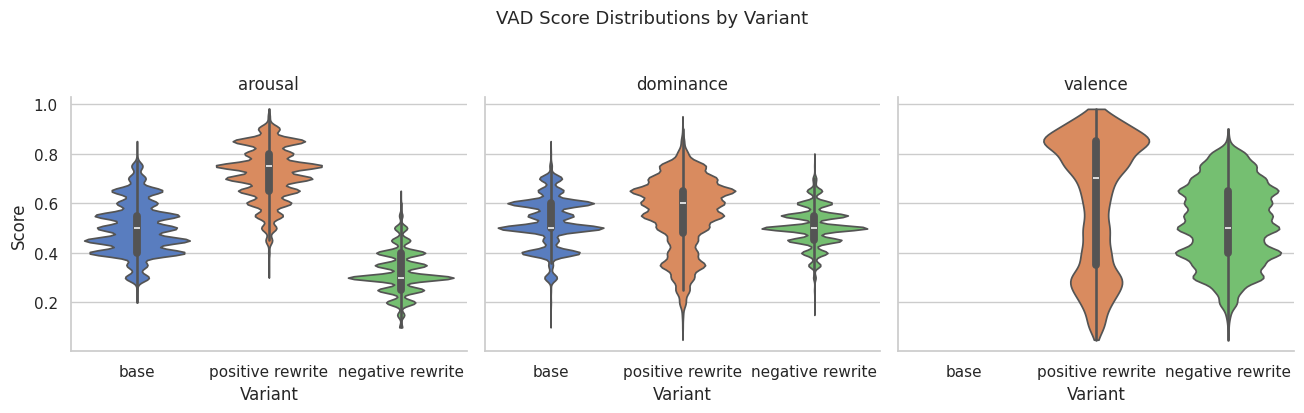

In [6]:
# Melt VAD scores into long form for violin plots
vad_long = df[VAD_COLS].melt(var_name="score_type", value_name="score")

def vad_group(name):
    if name.startswith("base"):
        return "base"
    elif name.startswith("positive"):
        return "positive rewrite"
    else:
        return "negative rewrite"

vad_long["variant"] = vad_long["score_type"].map(vad_group)
vad_long["dimension"] = vad_long["score_type"].str.split("_").str[-1]  # valence/arousal/dominance

g = sns.FacetGrid(
    vad_long,
    col="dimension",
    height=4,
    aspect=1.1,
)
g.map_dataframe(
    sns.violinplot,
    x="variant",
    y="score",
    order=["base", "positive rewrite", "negative rewrite"],
    palette="muted",
    inner="box",
    cut=0,
)
g.set_axis_labels("Variant", "Score")
g.set_titles(col_template="{col_name}")
g.figure.suptitle("VAD Score Distributions by Variant", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

## 8. Correlation Matrix of Numeric Scores

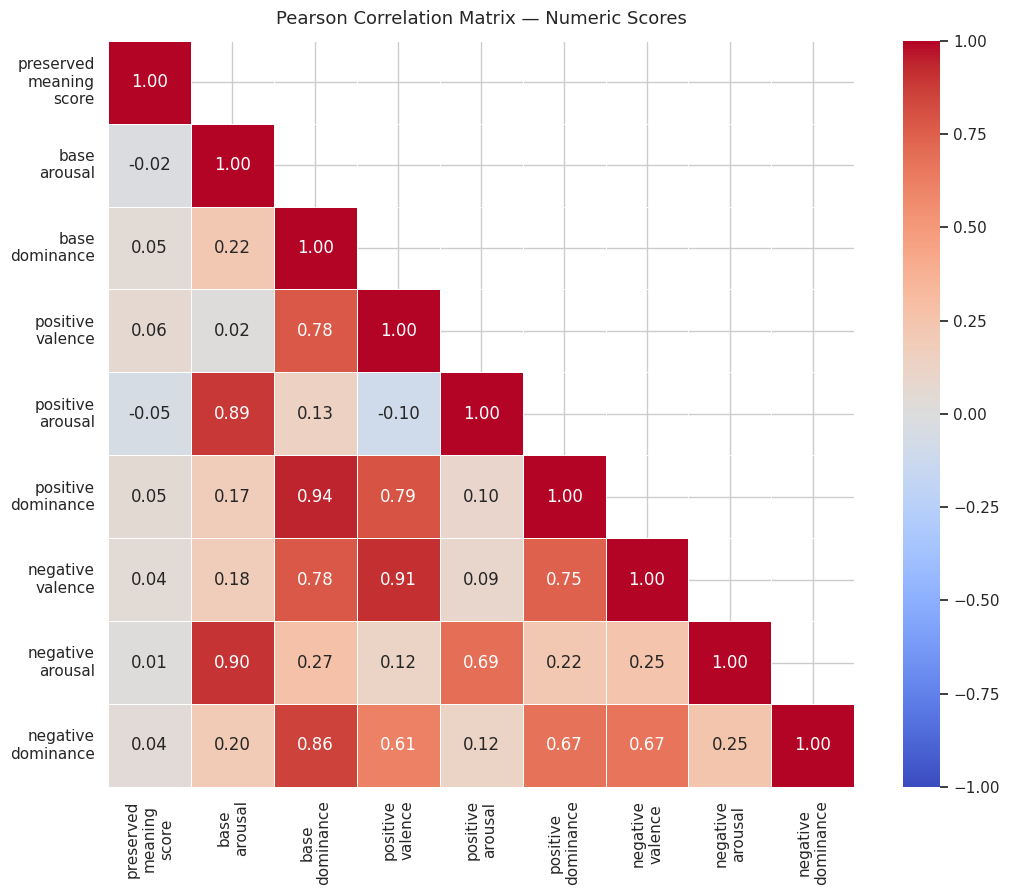

In [7]:
corr = df[score_cols].corr()

# Shorten labels for readability
short_labels = [c.replace("_", "\n") for c in score_cols]

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle mask (keep lower + diag)
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    xticklabels=short_labels,
    yticklabels=short_labels,
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix — Numeric Scores", fontsize=13, pad=12)
plt.tight_layout()
plt.show()